# Lab 03 — Edge Detection Techniques and Their Impact on Classification Performance

**Objectives:** implement first/second-order and multi-stage edge detectors, study the effect of noise and smoothing on edge quality, tune Canny parameters, and compare classification performance on Raw vs Filtered vs Edge-map image representations.

**Continuity with Lab 01 / Lab 02:**
- Same dataset (HAM10000) and same 4 classes: `nv`, `mel`, `bkl`, `bcc`
- Best filter from Lab 02: **Gaussian** (consistently improved all 3 models — Lab 02, Q5)
- Best 3 models from Lab 01: **VGG16, ResNet18, AlexNet** — VGG16 and ResNet18 are used here as "CNN Model 1/2"

**Sections:**
1. Setup & Dataset Preparation
2. Task 1 — Comparative Edge Detection (Sobel Gx/Gy/Magnitude, Prewitt, Laplacian, LoG, Canny)
3. Task 2 — Effect of Noise on Edge Detection (Table 1)
4. Task 3 — Canny Parameter Analysis (Table 2)
5. Task 4 — Dataset Preparation for Classification (Raw / Filtered / Edge)
6. Task 5 — Classification Performance Comparison (Table 3): SVM, Random Forest, KNN, CNN Model 1 (ResNet18), CNN Model 2 (VGG16)
7. Task 6 — Visual Comparison (confusion matrices + bar chart)
8. Discussion & Viva Questions
9. GitHub Submission

⚠️ Task 5 trains/evaluates **5 models × 3 dataset versions = 15 runs** (2 of which are full CNN fine-tuning ×3 = 6 epoch-based runs). Keep `EPOCHS` and `MAX_IMAGES_PER_CLASS` small first to confirm everything works, then raise them for your final numbers.

Set the runtime to GPU first: `Runtime > Change runtime type > T4 GPU`.

In [1]:
!pip install -q kagglehub opencv-python-headless scikit-learn scikit-image seaborn xgboost

## Section 1: Setup & Dataset Preparation

Same HAM10000 dataset and same 4 classes as Lab 01 / Lab 02, downloaded directly into Colab via `kagglehub` — no `kaggle.json` file needed (you'll paste your Kaggle username + API key once when prompted).

In [2]:
import kagglehub, os, glob
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset downloaded to:", path)

metadata_path = glob.glob(os.path.join(path, "**", "HAM10000_metadata.csv"), recursive=True)[0]
df = pd.read_csv(metadata_path)

image_paths = {}
for f in glob.glob(os.path.join(path, "**", "*.jpg"), recursive=True):
    image_id = os.path.splitext(os.path.basename(f))[0]
    image_paths[image_id] = f

df["path"] = df["image_id"].map(image_paths)
df = df.dropna(subset=["path"]).reset_index(drop=True)
print("Total labeled images found:", len(df))

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset downloaded to: /kaggle/input/skin-cancer-mnist-ham10000
Total labeled images found: 10015


In [3]:
# ---- EDIT THESE if you want different classes / dataset size ----
SELECTED_CLASSES = ["nv", "mel", "bkl", "bcc"]   # same 4 classes as Lab 01 / Lab 02
MAX_IMAGES_PER_CLASS = 250

subset = df[df["dx"].isin(SELECTED_CLASSES)].copy()
balanced_parts = []
for cls in SELECTED_CLASSES:
    cls_df = subset[subset["dx"] == cls]
    n = min(len(cls_df), MAX_IMAGES_PER_CLASS)
    balanced_parts.append(cls_df.sample(n=n, random_state=42))
subset = pd.concat(balanced_parts).reset_index(drop=True)

class_to_idx = {cls: i for i, cls in enumerate(SELECTED_CLASSES)}
subset["label"] = subset["dx"].map(class_to_idx)
print(subset["dx"].value_counts())
print("Total images used:", len(subset))

dx
nv     250
mel    250
bkl    250
bcc    250
Name: count, dtype: int64
Total images used: 1000


In [4]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(subset, test_size=0.3, stratify=subset["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
# This same split is reused for every experiment in this notebook for a fair comparison.

Train: 700  Val: 150  Test: 150


In [5]:
def load_rgb(path, size=256):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    return img

def to_gray(img_rgb):
    return cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

def normalize_uint8(img):
    img = img.astype(np.float64)
    img = img - img.min()
    maxv = img.max()
    if maxv > 0:
        img = img / maxv
    return (img * 255).astype(np.uint8)

# One representative image per class, used throughout Tasks 1-3
sample_images = {}
for cls in SELECTED_CLASSES:
    p = subset[subset["dx"] == cls]["path"].iloc[0]
    sample_images[cls] = load_rgb(p)
print("Sample images ready for:", list(sample_images.keys()))

Sample images ready for: ['nv', 'mel', 'bkl', 'bcc']


## Section 2 — Task 1: Comparative Edge Detection

Implements Sobel (Gx, Gy, magnitude), Prewitt, Laplacian, LoG, and Canny, then shows **Original → Sobel → Prewitt → Laplacian → LoG → Canny** for 3 classes.

In [6]:
def sobel_gx(gray):
    g = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    return normalize_uint8(np.abs(g))

def sobel_gy(gray):
    g = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    return normalize_uint8(np.abs(g))

def sobel_magnitude(gray):
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(gx**2 + gy**2)
    return normalize_uint8(mag)

def prewitt(gray):
    kx = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype=np.float64)
    ky = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=np.float64)
    gx = cv2.filter2D(gray.astype(np.float64), -1, kx)
    gy = cv2.filter2D(gray.astype(np.float64), -1, ky)
    mag = np.sqrt(gx**2 + gy**2)
    return normalize_uint8(mag)

def laplacian(gray):
    lap = cv2.Laplacian(gray, cv2.CV_64F, ksize=3)
    return normalize_uint8(np.abs(lap))

def log_filter(gray, ksize=5, sigma=1.4):
    blurred = cv2.GaussianBlur(gray, (ksize, ksize), sigma)
    lap = cv2.Laplacian(blurred, cv2.CV_64F, ksize=3)
    return normalize_uint8(np.abs(lap))

def canny_edge(gray, low=50, high=150, aperture=3):
    return cv2.Canny(gray, low, high, apertureSize=aperture, L2gradient=True)

EDGE_METHODS = {
    "Sobel": sobel_magnitude,
    "Prewitt": prewitt,
    "Laplacian": laplacian,
    "LoG": log_filter,
    "Canny": canny_edge,
}

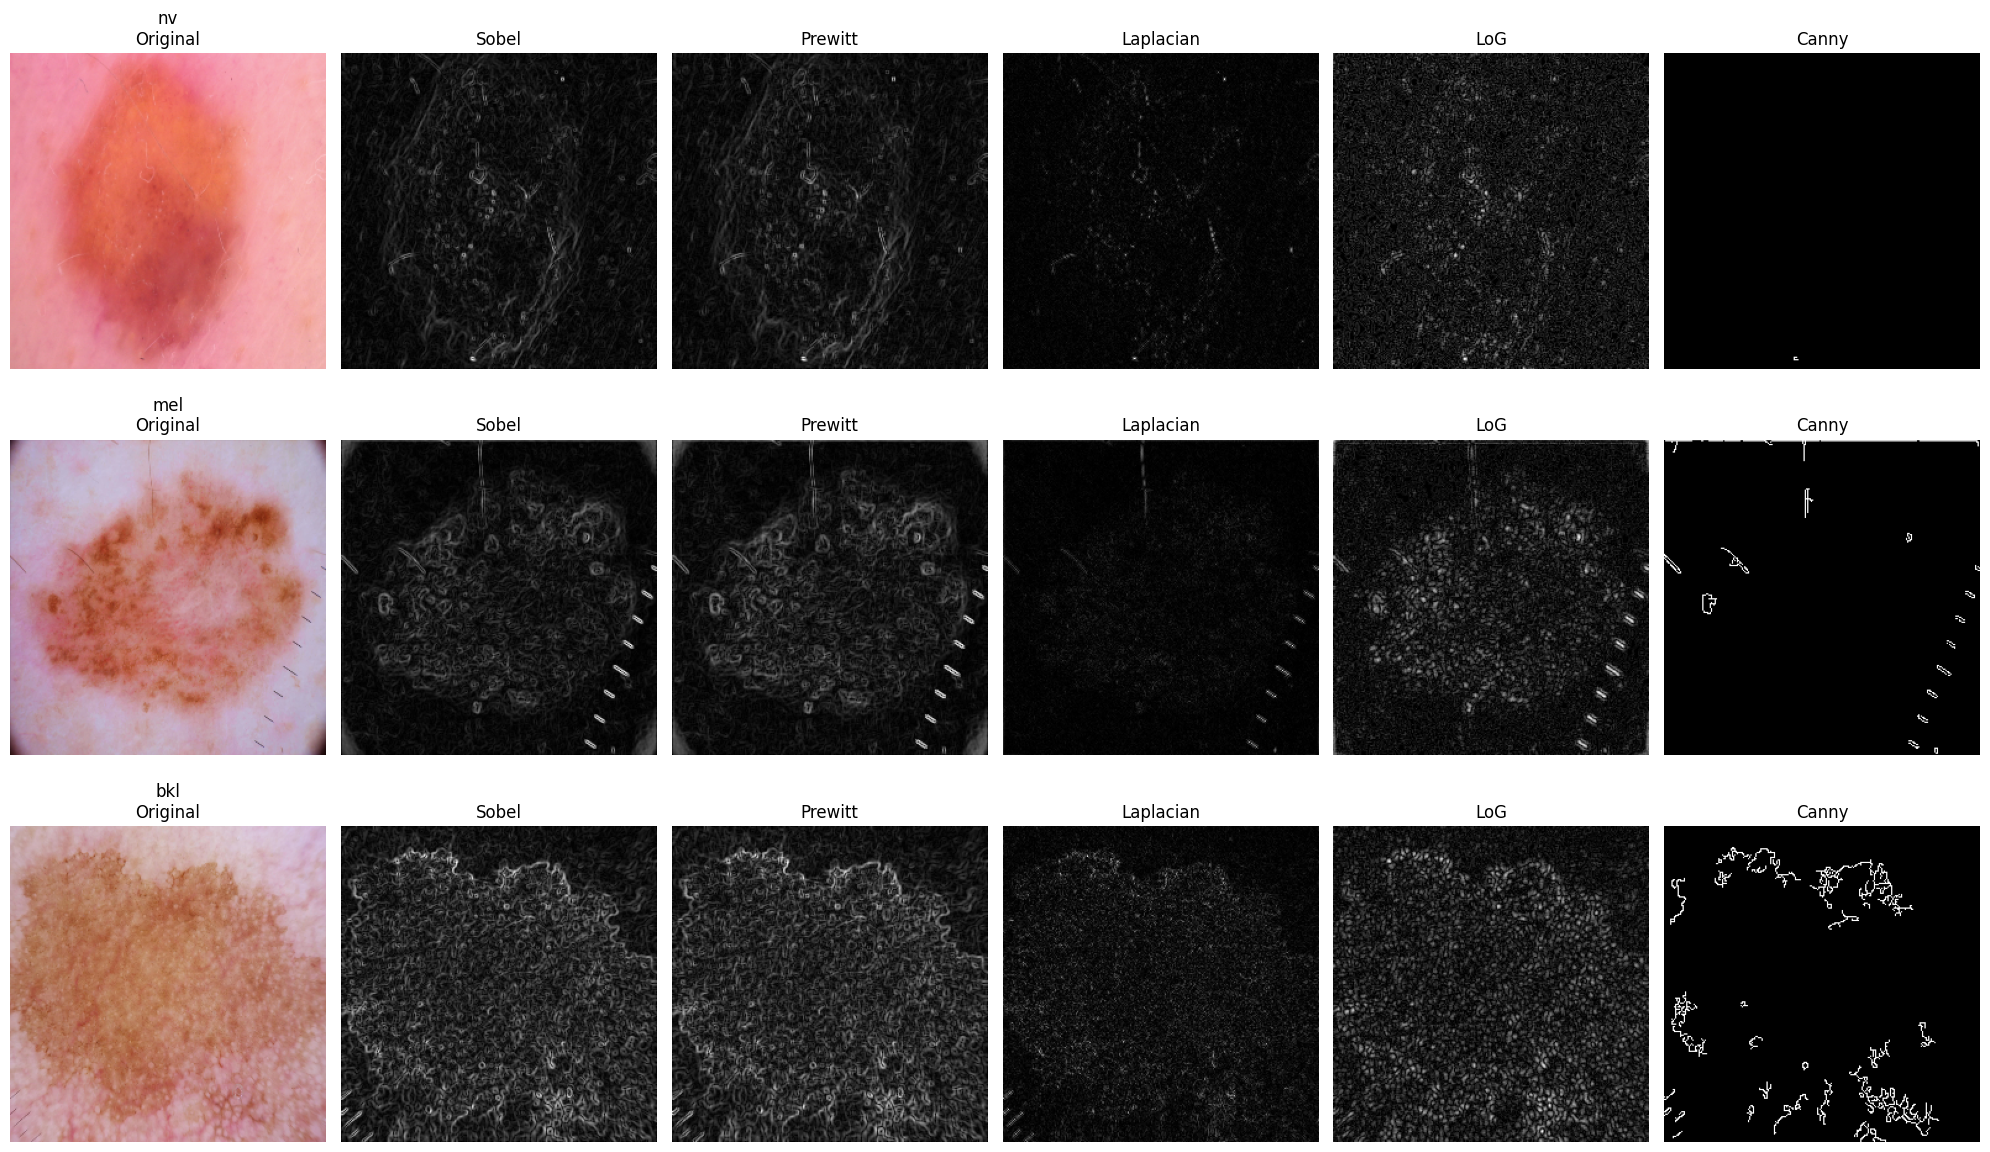

In [7]:
# Required figure: Original -> Sobel -> Prewitt -> Laplacian -> LoG -> Canny, for 3 classes
demo_classes = SELECTED_CLASSES[:3]
fig, axes = plt.subplots(len(demo_classes), 6, figsize=(20, 4 * len(demo_classes)))

for i, cls in enumerate(demo_classes):
    img_rgb = sample_images[cls]
    gray = to_gray(img_rgb)
    axes[i, 0].imshow(img_rgb); axes[i, 0].set_title(f"{cls}\nOriginal")
    axes[i, 1].imshow(sobel_magnitude(gray), cmap="gray"); axes[i, 1].set_title("Sobel")
    axes[i, 2].imshow(prewitt(gray), cmap="gray"); axes[i, 2].set_title("Prewitt")
    axes[i, 3].imshow(laplacian(gray), cmap="gray"); axes[i, 3].set_title("Laplacian")
    axes[i, 4].imshow(log_filter(gray), cmap="gray"); axes[i, 4].set_title("LoG")
    axes[i, 5].imshow(canny_edge(gray), cmap="gray"); axes[i, 5].set_title("Canny")
    for j in range(6):
        axes[i, j].axis("off")

plt.tight_layout()
plt.savefig("task1_edge_comparison.png", dpi=150)
plt.show()

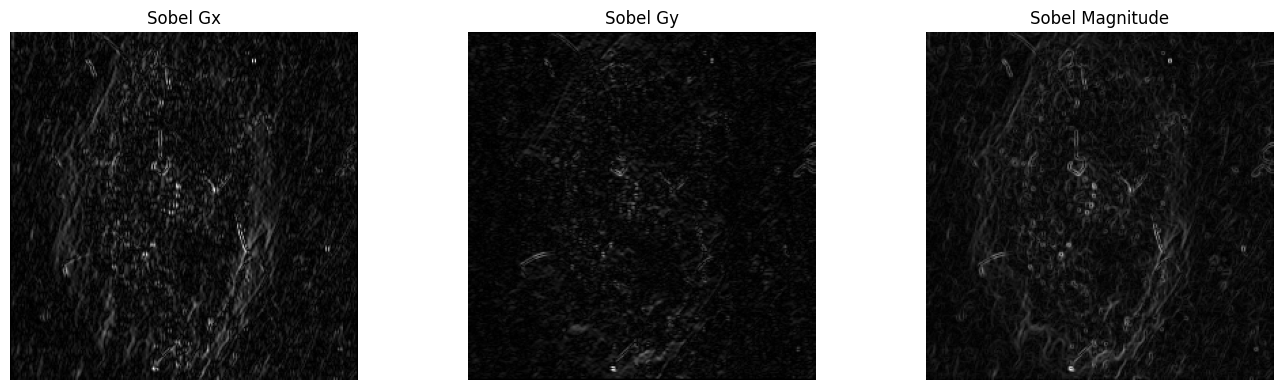

In [8]:
# Also show Sobel Gx and Gy separately (required sub-parts A.1 and A.2)
gray0 = to_gray(sample_images[demo_classes[0]])
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(sobel_gx(gray0), cmap="gray"); axes[0].set_title("Sobel Gx")
axes[1].imshow(sobel_gy(gray0), cmap="gray"); axes[1].set_title("Sobel Gy")
axes[2].imshow(sobel_magnitude(gray0), cmap="gray"); axes[2].set_title("Sobel Magnitude")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()

## Section 3 — Task 2: Effect of Noise on Edge Detection

Adds Gaussian noise and Salt-and-Pepper noise, applies edge detectors to original / noisy / noisy+Gaussian-filtered / noisy+Median-filtered versions, and auto-fills **Table 1** using two quantitative metrics:
- **Edge Density (%)** — fraction of pixels marked as edges
- **Noise Sensitivity (%)** — `(1 - SSIM)` between this edge map and the clean-original edge map for the *same detector* (higher = more different from the clean baseline = more noise-sensitive)

In [9]:
def add_gaussian_noise(img_rgb, mean=0, sigma=25):
    noise = np.random.normal(mean, sigma, img_rgb.shape)
    noisy = img_rgb.astype(np.float64) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def add_salt_pepper_noise(img_rgb, amount=0.02, s_vs_p=0.5):
    noisy = img_rgb.copy()
    h, w = img_rgb.shape[:2]
    n_salt = int(amount * h * w * s_vs_p)
    n_pepper = int(amount * h * w * (1 - s_vs_p))

    ys = np.random.randint(0, h, n_salt); xs = np.random.randint(0, w, n_salt)
    noisy[ys, xs] = 255
    ys = np.random.randint(0, h, n_pepper); xs = np.random.randint(0, w, n_pepper)
    noisy[ys, xs] = 0
    return noisy

def apply_gaussian_filter(img_rgb, ksize=5):
    return cv2.GaussianBlur(img_rgb, (ksize, ksize), 0)

def apply_median_filter(img_rgb, ksize=5):
    return cv2.medianBlur(img_rgb, ksize)

In [10]:
from skimage.metrics import structural_similarity as ssim

def edge_density(edge_img):
    return 100 * np.count_nonzero(edge_img) / edge_img.size

def noise_sensitivity(clean_edge, test_edge):
    score, _ = ssim(clean_edge, test_edge, full=True)
    return (1 - score) * 100

def get_edge_map(gray, detector):
    return EDGE_METHODS[detector](gray)

In [11]:
demo_img = sample_images[SELECTED_CLASSES[0]]
gray_clean = to_gray(demo_img)

gaussian_noisy = add_gaussian_noise(demo_img)
sp_noisy = add_salt_pepper_noise(demo_img)

gaussian_noisy_filtered = apply_gaussian_filter(gaussian_noisy)
sp_noisy_filtered = apply_median_filter(sp_noisy)

# Precompute clean baseline edge map for each detector (used for Noise Sensitivity)
clean_edges = {name: get_edge_map(gray_clean, name) for name in EDGE_METHODS}

table1_rows = [
    ("Sobel", "Original", "None", "None", gray_clean),
    ("Sobel", "Noisy", "Gaussian", "None", to_gray(gaussian_noisy)),
    ("Sobel", "Noisy", "Salt & Pepper", "None", to_gray(sp_noisy)),
    ("Sobel", "Noisy", "Gaussian", "Gaussian Filter", to_gray(gaussian_noisy_filtered)),
    ("Sobel", "Noisy", "Salt & Pepper", "Median Filter", to_gray(sp_noisy_filtered)),
    ("Prewitt", "Original", "None", "None", gray_clean),
    ("Laplacian", "Original", "None", "None", gray_clean),
    ("LoG", "Noisy", "Gaussian", "Gaussian Filter", to_gray(gaussian_noisy_filtered)),
    ("Canny", "Original", "None", "Built-in smoothing", gray_clean),
    ("Canny", "Noisy", "Gaussian", "Gaussian Filter", to_gray(gaussian_noisy_filtered)),
    ("Canny", "Noisy", "Salt & Pepper", "Median Filter", to_gray(sp_noisy_filtered)),
]

def make_observation(detector, density, sensitivity):
    notes = []
    if sensitivity < 5:
        notes.append("edge map nearly identical to clean baseline, good continuity, no visible false edges")
    elif sensitivity < 20:
        notes.append("minor differences from clean baseline, mostly continuous edges, few false edges")
    elif sensitivity < 40:
        notes.append("noticeable false edges and some broken segments, moderate noise sensitivity")
    else:
        notes.append("heavy false-edge scattering, broken/fragmented edges, high noise sensitivity")
    if density > 15:
        notes.append("edge map is dense/noisy-looking")
    elif density < 2:
        notes.append("edge map is sparse, may be under-detecting")
    return "; ".join(notes)

table1_results = []
for detector, input_img, noise_type, preprocessing, gray_img in table1_rows:
    edge_map = get_edge_map(gray_img, detector)
    density = edge_density(edge_map)
    sensitivity = noise_sensitivity(clean_edges[detector], edge_map)
    obs = make_observation(detector, density, sensitivity)
    table1_results.append({
        "Edge Detector": detector, "Input Image": input_img, "Noise Type": noise_type,
        "Preprocessing": preprocessing, "Edge Quality (density %)": round(density, 2),
        "Noise Sensitivity (%)": round(sensitivity, 2), "Observations": obs,
    })

table1_df = pd.DataFrame(table1_results)
table1_df

,Edge Detector,Input Image,Noise Type,Preprocessing,Edge Quality (density %),Noise Sensitivity (%),Observations
0,Sobel,Original,None,None,99.39,0.00,"edge map nearly identical to clean baseline, g..."
1,Sobel,Noisy,Gaussian,None,99.96,95.73,"heavy false-edge scattering, broken/fragmented..."
2,Sobel,Noisy,Salt & Pepper,None,96.46,82.95,"heavy false-edge scattering, broken/fragmented..."
3,Sobel,Noisy,Gaussian,Gaussian Filter,99.84,92.16,"heavy false-edge scattering, broken/fragmented..."
4,Sobel,Noisy,Salt & Pepper,Median Filter,95.25,55.31,"heavy false-edge scattering, broken/fragmented..."
5,Prewitt,Original,None,None,99.49,0.00,"edge map nearly identical to clean baseline, g..."
6,Laplacian,Original,None,None,93.62,0.00,"edge map nearly identical to clean baseline, g..."
7,LoG,Noisy,Gaussian,Gaussian Filter,87.08,93.43,"heavy false-edge scattering, broken/fragmented..."
8,Canny,Original,None,Built-in smoothing,0.01,0.00,"edge map nearly identical to clean baseline, g..."
9,Canny,Noisy,Gaussian,Gaussian Filter,0.00,0.14,"edge map nearly identical to clean baseline, g..."


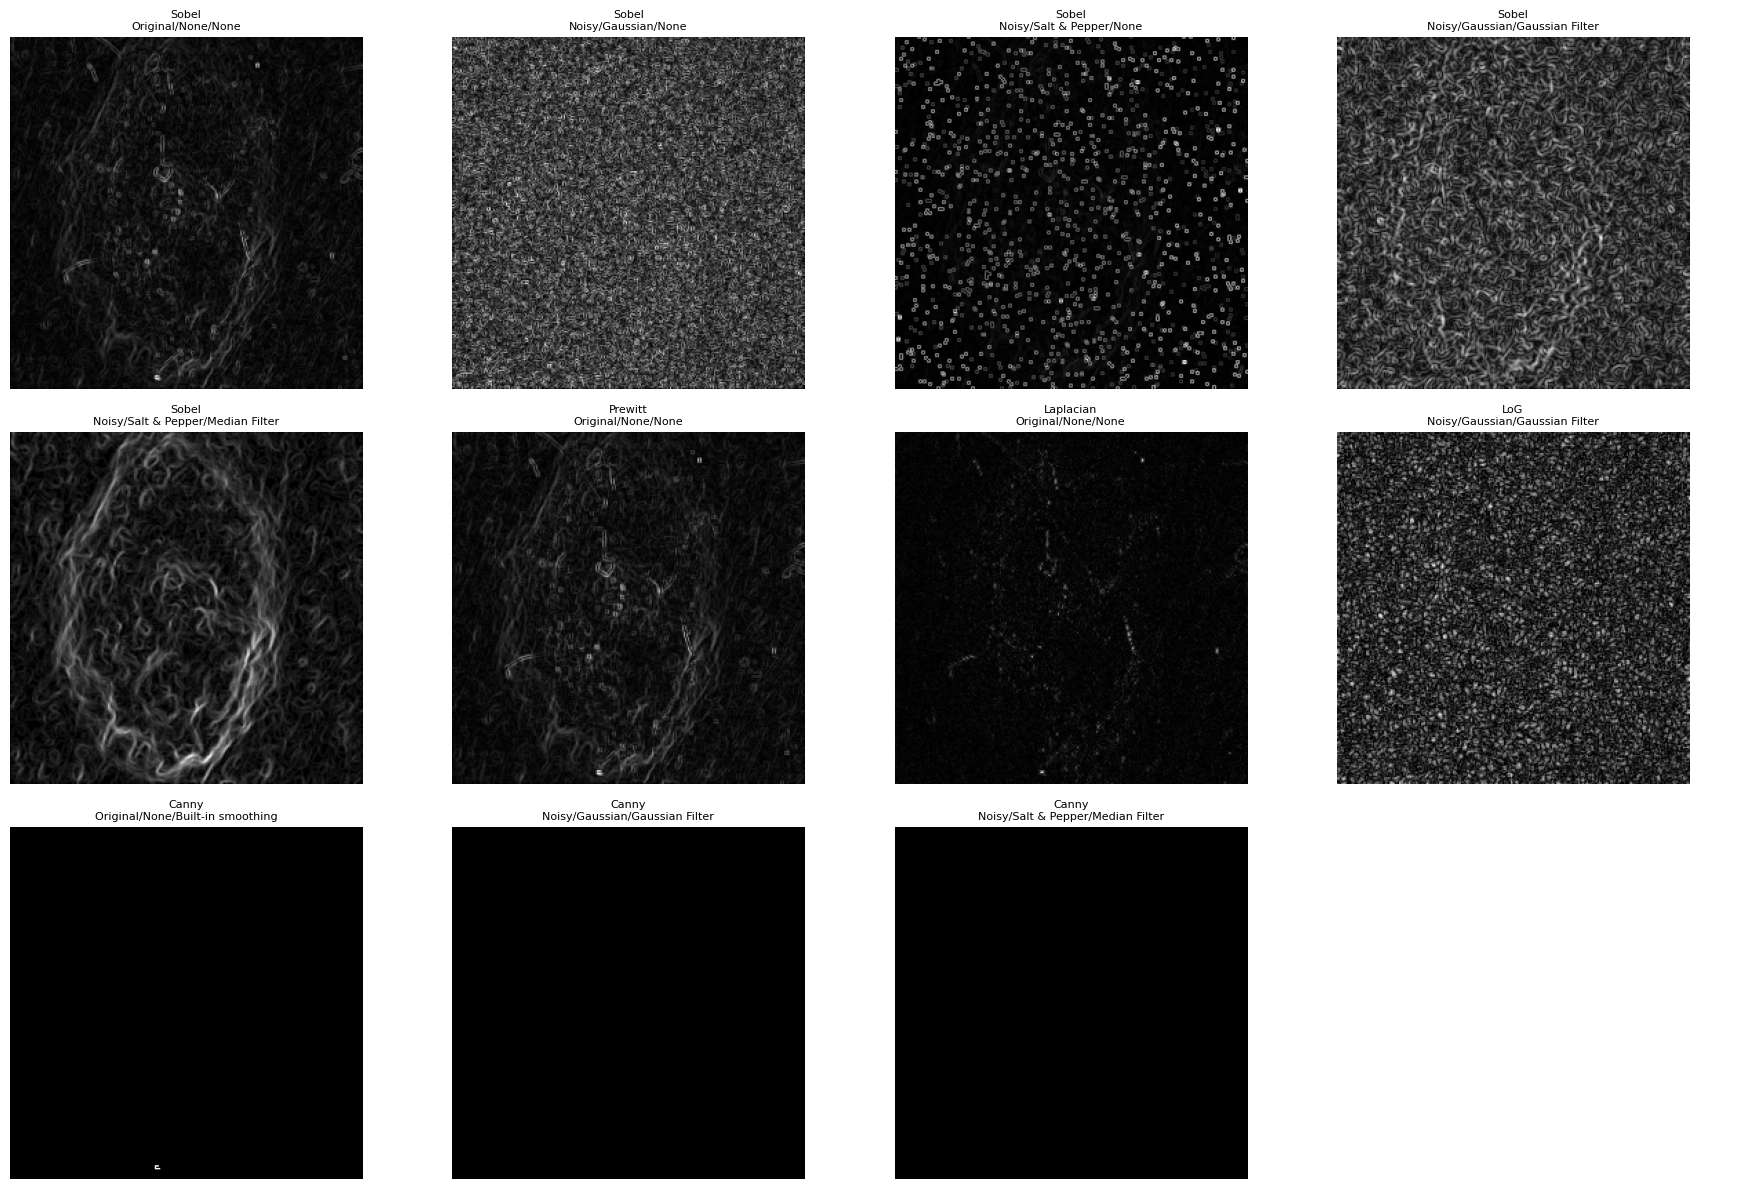

In [12]:
table1_df.to_csv("table1_noise_effect.csv", index=False)

# Visualize the 11 conditions
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, (detector, input_img, noise_type, preprocessing, gray_img) in enumerate(table1_rows):
    edge_map = get_edge_map(gray_img, detector)
    axes[i].imshow(edge_map, cmap="gray")
    axes[i].set_title(f"{detector}\n{input_img}/{noise_type}/{preprocessing}", fontsize=8)
    axes[i].axis("off")
for j in range(len(table1_rows), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.savefig("task2_noise_effect.png", dpi=150)
plt.show()

## Section 4 — Task 3: Parameter Analysis of Canny Edge Detection

Tests 3 threshold combinations at 3×3 kernel, plus a 5×5 kernel variant, and auto-fills **Table 2**.

In [13]:
canny_configs = [
    {"name": "Canny-1", "low": 30,  "high": 100, "kernel": 3},
    {"name": "Canny-2", "low": 50,  "high": 150, "kernel": 3},
    {"name": "Canny-3", "low": 100, "high": 200, "kernel": 3},
    {"name": "Canny-4", "low": 50,  "high": 150, "kernel": 5},  # same thresholds as Canny-2, larger kernel
]

table2_results = []
canny_edge_maps = {}
for cfg in canny_configs:
    edge_map = canny_edge(gray_clean, low=cfg["low"], high=cfg["high"], aperture=cfg["kernel"])
    canny_edge_maps[cfg["name"]] = edge_map
    density = edge_density(edge_map)
    n_edges = int(np.count_nonzero(edge_map))
    if density < 3:
        quality = "Sparse / under-detecting"
    elif density > 15:
        quality = "Dense / noisy"
    else:
        quality = "Balanced"
    table2_results.append({
        "Configuration": cfg["name"], "Low Threshold": cfg["low"], "High Threshold": cfg["high"],
        "Kernel Size": f"{cfg['kernel']}x{cfg['kernel']}", "Edge Quality": quality,
        "Number of Detected Edges": n_edges, "Observation": f"{density:.2f}% of pixels marked as edges",
    })

table2_df = pd.DataFrame(table2_results)
table2_df

,Configuration,Low Threshold,High Threshold,Kernel Size,Edge Quality,Number of Detected Edges,Observation
0,Canny-1,30,100,3x3,Sparse / under-detecting,245,0.37% of pixels marked as edges
1,Canny-2,50,150,3x3,Sparse / under-detecting,8,0.01% of pixels marked as edges
2,Canny-3,100,200,3x3,Sparse / under-detecting,0,0.00% of pixels marked as edges
3,Canny-4,50,150,5x5,Dense / noisy,18765,28.63% of pixels marked as edges


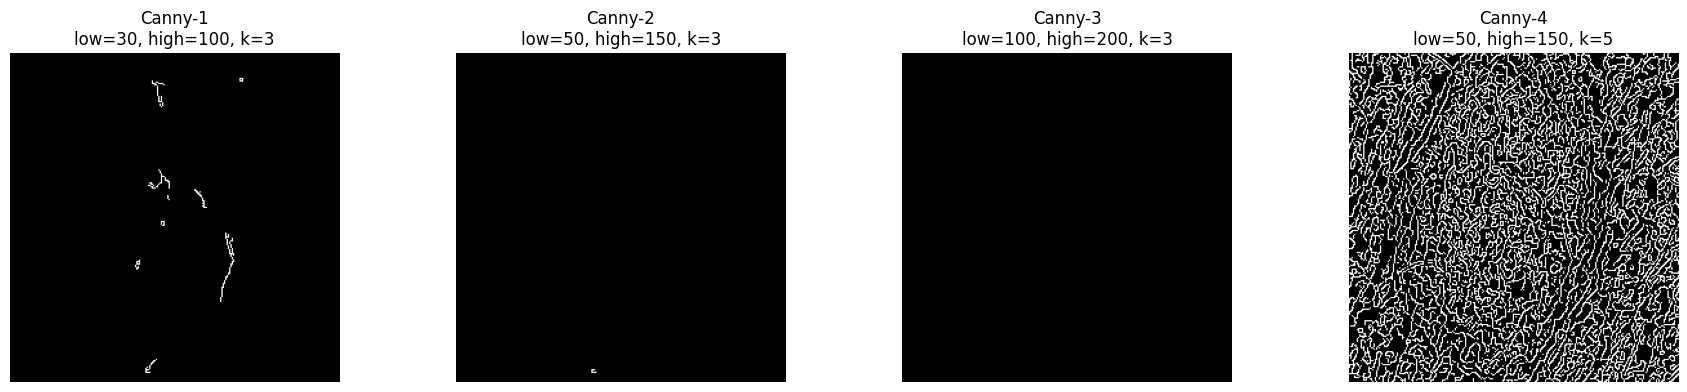

In [14]:
table2_df.to_csv("table2_canny_params.csv", index=False)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, cfg in zip(axes, canny_configs):
    ax.imshow(canny_edge_maps[cfg["name"]], cmap="gray")
    ax.set_title(f"{cfg['name']}\nlow={cfg['low']}, high={cfg['high']}, k={cfg['kernel']}")
    ax.axis("off")
plt.tight_layout()
plt.savefig("task3_canny_params.png", dpi=150)
plt.show()

In [15]:
# Auto-select the "most useful" configuration: closest edge density to a balanced 5-12% target range
def density_score(row):
    d = row["Number of Detected Edges"] / gray_clean.size * 100
    target_mid = 8.0
    return abs(d - target_mid)

table2_df["_score"] = table2_df.apply(density_score, axis=1)
best_row = table2_df.loc[table2_df["_score"].idxmin()]
best_config_name = best_row["Configuration"]
best_cfg = next(c for c in canny_configs if c["name"] == best_config_name)
table2_df = table2_df.drop(columns=["_score"])

print(f"Selected best Canny configuration: {best_config_name} "
      f"(low={best_cfg['low']}, high={best_cfg['high']}, kernel={best_cfg['kernel']})")
print("This is used as the 'best edge detection method' for Task 4 (Set C).")

BEST_CANNY_LOW = best_cfg["low"]
BEST_CANNY_HIGH = best_cfg["high"]
BEST_CANNY_KERNEL = best_cfg["kernel"]

Selected best Canny configuration: Canny-1 (low=30, high=100, kernel=3)
This is used as the 'best edge detection method' for Task 4 (Set C).


## Section 5 — Task 4: Dataset Preparation for Classification

Three versions of the same train/val/test split:
- **Set A — Raw**: original images (Lab 01)
- **Set B — Filtered**: Gaussian filter (best filter from Lab 02)
- **Set C — Edge**: best Canny configuration selected above (Task 1–3), replicated to 3 channels so it fits the same model input shape

In [16]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class VersionTransform:
    """Turns a PIL image into Raw / Filtered / Edge, as a PIL image, before the usual ToTensor+Normalize."""
    def __init__(self, version):
        self.version = version  # "Raw", "Filtered", "Edge"

    def __call__(self, pil_img):
        img_np = np.array(pil_img)
        if self.version == "Raw":
            return Image.fromarray(img_np)
        elif self.version == "Filtered":
            filtered = apply_gaussian_filter(img_np)
            return Image.fromarray(filtered)
        elif self.version == "Edge":
            gray = to_gray(img_np)
            edge = canny_edge(gray, low=BEST_CANNY_LOW, high=BEST_CANNY_HIGH, aperture=BEST_CANNY_KERNEL)
            edge_3ch = cv2.cvtColor(edge, cv2.COLOR_GRAY2RGB)
            return Image.fromarray(edge_3ch)
        else:
            raise ValueError(self.version)

class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, row["label"]

BATCH_SIZE = 32
IMG_MEAN, IMG_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

def get_dataloaders(version):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        VersionTransform(version),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMG_MEAN, std=IMG_STD),
    ])
    train_loader = DataLoader(HAM10000Dataset(train_df, transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader   = DataLoader(HAM10000Dataset(val_df, transform),   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader  = DataLoader(HAM10000Dataset(test_df, transform),  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    return train_loader, val_loader, test_loader

DATASET_VERSIONS = ["Raw", "Filtered", "Edge"]

Using device: cuda


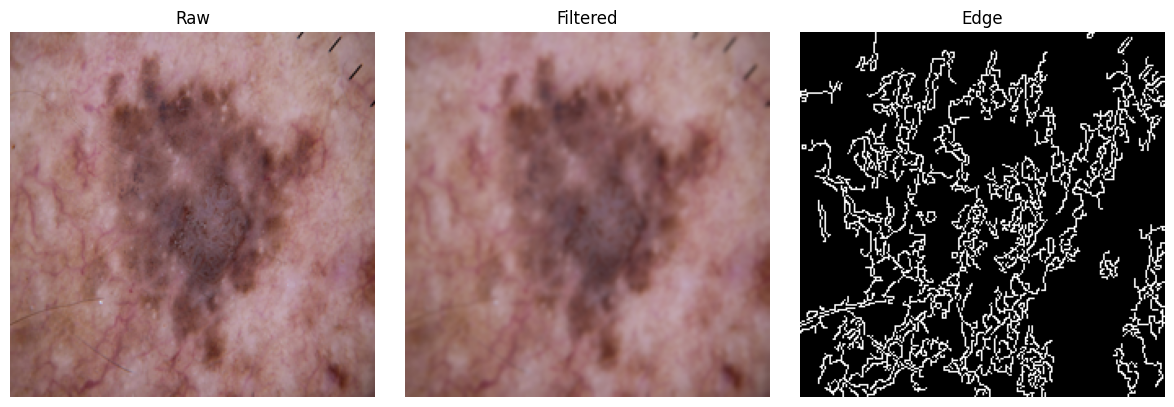

In [17]:
# Visual check: same image in all 3 versions
sample_path = train_df["path"].iloc[0]
sample_pil = Image.open(sample_path).convert("RGB").resize((224, 224))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, version in zip(axes, DATASET_VERSIONS):
    transformed = VersionTransform(version)(sample_pil)
    ax.imshow(transformed, cmap="gray" if version == "Edge" else None)
    ax.set_title(version)
    ax.axis("off")
plt.tight_layout()
plt.savefig("task4_dataset_versions.png", dpi=150)
plt.show()

## Section 6 — Task 5: Classification Performance Comparison

Trains **5 models × 3 dataset versions = 15 runs**:
- **SVM, Random Forest, KNN** — classical classifiers on 512-dim ResNet18 features (frozen, ImageNet-pretrained, no fine-tuning)
- **CNN Model 1 (ResNet18)**, **CNN Model 2 (VGG16)** — fully fine-tuned end-to-end

For each run we record Accuracy, Precision, Recall, F1-score, Training Time, and Inference Time. Table 3 asks for one Precision/Recall/F1/Training-Time/Inference-Time per model (not per dataset version) — we report those from each model's **best-accuracy dataset version**, and show all three Accuracy columns for direct comparison.

In [18]:
EPOCHS = 5  # keep small first; raise for final submission numbers
NUM_CLASSES = len(SELECTED_CLASSES)

def build_cnn(name):
    if name == "CNN Model 1 (ResNet18)":
        m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    elif name == "CNN Model 2 (VGG16)":
        m = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        m.classifier[6] = nn.Linear(4096, NUM_CLASSES)
    else:
        raise ValueError(name)
    return m.to(device)

In [19]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def run_epoch(model, loader, criterion, optimizer, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train: optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train:
                loss.backward(); optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

def train_cnn(model, train_loader, val_loader, epochs=EPOCHS):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    start = time.time()
    for epoch in range(epochs):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
        va_loss, va_acc = run_epoch(model, val_loader, criterion, optimizer, train=False)
        print(f"    Epoch {epoch+1}/{epochs}  train_acc={tr_acc:.3f}  val_acc={va_acc:.3f}")
    training_time = time.time() - start
    return model, training_time

def evaluate_cnn(model, test_loader, n_test):
    model.eval()
    all_labels, all_preds = [], []
    start = time.time()
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu().numpy()
            all_labels.extend(labels.numpy())
            all_preds.extend(preds)
    total_time = time.time() - start
    inference_time_ms = (total_time / n_test) * 1000

    y_true, y_pred = np.array(all_labels), np.array(all_preds)
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred) * 100,
        "Precision": precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100,
        "Recall": recall_score(y_true, y_pred, average='weighted', zero_division=0) * 100,
        "F1-Score": f1_score(y_true, y_pred, average='weighted', zero_division=0) * 100,
    }
    cm = confusion_matrix(y_true, y_pred)
    return metrics, cm, inference_time_ms, y_true, y_pred

In [20]:
all_run_results = []      # every (model, dataset version) row
all_confusion_task6 = {}  # keyed by (model, version) for the best model later

def run_cnn_experiment(model_name, version):
    print(f"\n=== {model_name} | {version} ===")
    train_loader, val_loader, test_loader = get_dataloaders(version)
    model = build_cnn(model_name)
    model, training_time = train_cnn(model, train_loader, val_loader)
    metrics, cm, inf_time, y_true, y_pred = evaluate_cnn(model, test_loader, len(test_df))
    print(f"  -> Accuracy={metrics['Accuracy']:.2f}%  Training Time={training_time:.1f}s  Inference={inf_time:.2f}ms")

    all_run_results.append({
        "Model": model_name, "Dataset": version, **metrics,
        "Training Time (s)": round(training_time, 2), "Inference Time (ms)": round(inf_time, 3),
    })
    all_confusion_task6[(model_name, version)] = cm
    del model
    torch.cuda.empty_cache() if device.type == "cuda" else None

for model_name in ["CNN Model 1 (ResNet18)", "CNN Model 2 (VGG16)"]:
    for version in DATASET_VERSIONS:
        run_cnn_experiment(model_name, version)


=== CNN Model 1 (ResNet18) | Raw ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s]


    Epoch 1/5  train_acc=0.556  val_acc=0.633
    Epoch 2/5  train_acc=0.914  val_acc=0.727
    Epoch 3/5  train_acc=0.993  val_acc=0.713
    Epoch 4/5  train_acc=0.999  val_acc=0.740
    Epoch 5/5  train_acc=1.000  val_acc=0.740
  -> Accuracy=67.33%  Training Time=43.4s  Inference=12.65ms

=== CNN Model 1 (ResNet18) | Filtered ===
    Epoch 1/5  train_acc=0.547  val_acc=0.640
    Epoch 2/5  train_acc=0.896  val_acc=0.700
    Epoch 3/5  train_acc=0.983  val_acc=0.700
    Epoch 4/5  train_acc=1.000  val_acc=0.707
    Epoch 5/5  train_acc=1.000  val_acc=0.727
  -> Accuracy=66.67%  Training Time=40.8s  Inference=12.59ms

=== CNN Model 1 (ResNet18) | Edge ===
    Epoch 1/5  train_acc=0.361  val_acc=0.327
    Epoch 2/5  train_acc=0.804  val_acc=0.387
    Epoch 3/5  train_acc=0.967  val_acc=0.400
    Epoch 4/5  train_acc=0.991  val_acc=0.387
    Epoch 5/5  train_acc=0.994  val_acc=0.420
  -> Accuracy=45.33%  Training Time=42.0s  Inference=9.12ms

=== CNN Model 2 (VGG16) | Raw ===
Downloading

100%|██████████| 528M/528M [00:03<00:00, 174MB/s]


    Epoch 1/5  train_acc=0.383  val_acc=0.593
    Epoch 2/5  train_acc=0.604  val_acc=0.633
    Epoch 3/5  train_acc=0.719  val_acc=0.627
    Epoch 4/5  train_acc=0.820  val_acc=0.627
    Epoch 5/5  train_acc=0.899  val_acc=0.627
  -> Accuracy=60.67%  Training Time=67.4s  Inference=13.13ms

=== CNN Model 2 (VGG16) | Filtered ===
    Epoch 1/5  train_acc=0.431  val_acc=0.547
    Epoch 2/5  train_acc=0.624  val_acc=0.587
    Epoch 3/5  train_acc=0.691  val_acc=0.647
    Epoch 4/5  train_acc=0.789  val_acc=0.600
    Epoch 5/5  train_acc=0.827  val_acc=0.647
  -> Accuracy=60.00%  Training Time=66.7s  Inference=10.81ms

=== CNN Model 2 (VGG16) | Edge ===
    Epoch 1/5  train_acc=0.280  val_acc=0.307
    Epoch 2/5  train_acc=0.376  val_acc=0.393
    Epoch 3/5  train_acc=0.443  val_acc=0.347
    Epoch 4/5  train_acc=0.491  val_acc=0.427
    Epoch 5/5  train_acc=0.580  val_acc=0.373
  -> Accuracy=45.33%  Training Time=65.5s  Inference=10.78ms


In [21]:
# Classical classifiers on frozen ResNet18 features
from sklearn.linear_model import LogisticRegression  # not required, but handy if you want to add more later
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

feature_extractor = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
feature_extractor.fc = nn.Identity()
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

def extract_features(loader):
    feats, labels_list = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            out = feature_extractor(imgs).cpu().numpy()
            feats.append(out)
            labels_list.append(labels.numpy())
    return np.concatenate(feats), np.concatenate(labels_list)

CLASSICAL_CLASSIFIERS = {
    "SVM": lambda: SVC(kernel="rbf", probability=True, random_state=42),
    "Random Forest": lambda: RandomForestClassifier(n_estimators=200, random_state=42),
    "KNN": lambda: KNeighborsClassifier(n_neighbors=5),
}

In [22]:
def run_classical_experiment(clf_name, version):
    print(f"\n=== {clf_name} | {version} ===")
    train_loader, val_loader, test_loader = get_dataloaders(version)

    X_train, y_train = extract_features(train_loader)
    X_test, y_test = extract_features(test_loader)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    clf = CLASSICAL_CLASSIFIERS[clf_name]()
    start = time.time()
    clf.fit(X_train_s, y_train)
    training_time = time.time() - start

    start = time.time()
    y_pred = clf.predict(X_test_s)
    inference_time_ms = (time.time() - start) / len(X_test_s) * 1000

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred) * 100,
        "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0) * 100,
        "Recall": recall_score(y_test, y_pred, average='weighted', zero_division=0) * 100,
        "F1-Score": f1_score(y_test, y_pred, average='weighted', zero_division=0) * 100,
    }
    cm = confusion_matrix(y_test, y_pred)
    print(f"  -> Accuracy={metrics['Accuracy']:.2f}%  Training Time={training_time:.2f}s  Inference={inference_time_ms:.3f}ms")

    all_run_results.append({
        "Model": clf_name, "Dataset": version, **metrics,
        "Training Time (s)": round(training_time, 2), "Inference Time (ms)": round(inference_time_ms, 3),
    })
    all_confusion_task6[(clf_name, version)] = cm

for clf_name in CLASSICAL_CLASSIFIERS:
    for version in DATASET_VERSIONS:
        run_classical_experiment(clf_name, version)

print("\nAll 15 runs complete.")


=== SVM | Raw ===
  -> Accuracy=60.67%  Training Time=0.74s  Inference=0.337ms

=== SVM | Filtered ===
  -> Accuracy=59.33%  Training Time=0.98s  Inference=0.461ms

=== SVM | Edge ===
  -> Accuracy=42.00%  Training Time=0.82s  Inference=0.357ms

=== Random Forest | Raw ===
  -> Accuracy=64.00%  Training Time=2.59s  Inference=0.110ms

=== Random Forest | Filtered ===
  -> Accuracy=62.67%  Training Time=2.56s  Inference=0.117ms

=== Random Forest | Edge ===
  -> Accuracy=42.67%  Training Time=3.15s  Inference=0.113ms

=== KNN | Raw ===
  -> Accuracy=50.67%  Training Time=0.00s  Inference=0.463ms

=== KNN | Filtered ===
  -> Accuracy=48.67%  Training Time=0.00s  Inference=0.091ms

=== KNN | Edge ===
  -> Accuracy=44.00%  Training Time=0.00s  Inference=0.133ms

All 15 runs complete.


In [23]:
run_results_df = pd.DataFrame(all_run_results)
run_results_df.to_csv("all_runs_raw.csv", index=False)
run_results_df

,Model,Dataset,Accuracy,Precision,Recall,F1-Score,Training Time (s),Inference Time (ms)
0,CNN Model 1 (ResNet18),Raw,67.333333,68.054545,67.333333,66.543554,43.40,12.653
1,CNN Model 1 (ResNet18),Filtered,66.666667,66.120557,66.666667,66.182446,40.77,12.589
2,CNN Model 1 (ResNet18),Edge,45.333333,45.718651,45.333333,45.442468,42.02,9.124
3,CNN Model 2 (VGG16),Raw,60.666667,69.510101,60.666667,56.031723,67.37,13.131
4,CNN Model 2 (VGG16),Filtered,60.000000,68.896776,60.000000,55.892480,66.72,10.811
5,CNN Model 2 (VGG16),Edge,45.333333,42.007843,45.333333,33.955556,65.46,10.775
6,SVM,Raw,60.666667,60.732377,60.666667,59.794203,0.74,0.337
7,SVM,Filtered,59.333333,59.229195,59.333333,58.796157,0.98,0.461
8,SVM,Edge,42.000000,38.921265,42.000000,39.446563,0.82,0.357
9,Random Forest,Raw,64.000000,63.840899,64.000000,63.041155,2.59,0.110


In [24]:
# Build Table 3 in the exact format the lab asks for
MODEL_ORDER = ["SVM", "Random Forest", "KNN", "CNN Model 1 (ResNet18)", "CNN Model 2 (VGG16)"]

table3_rows = []
for model_name in MODEL_ORDER:
    model_rows = run_results_df[run_results_df["Model"] == model_name]
    acc_by_version = {v: model_rows[model_rows["Dataset"] == v]["Accuracy"].values[0] for v in DATASET_VERSIONS}
    best_version = max(acc_by_version, key=acc_by_version.get)
    best_row = model_rows[model_rows["Dataset"] == best_version].iloc[0]

    table3_rows.append({
        "Model / Classifier": model_name,
        "Accuracy Raw (Lab 1) (%)": round(acc_by_version["Raw"], 2),
        "Accuracy Filtered (Lab 2) (%)": round(acc_by_version["Filtered"], 2),
        "Accuracy Edge (Lab 3) (%)": round(acc_by_version["Edge"], 2),
        "Precision (%)": round(best_row["Precision"], 2),
        "Recall (%)": round(best_row["Recall"], 2),
        "F1-Score (%)": round(best_row["F1-Score"], 2),
        "Training Time (s)": best_row["Training Time (s)"],
        "Inference Time (ms)": best_row["Inference Time (ms)"],
        "Best Dataset": best_version,
    })

table3_df = pd.DataFrame(table3_rows)
table3_df.to_csv("table3_classification_comparison.csv", index=False)
table3_df

,Model / Classifier,Accuracy Raw (Lab 1) (%),Accuracy Filtered (Lab 2) (%),Accuracy Edge (Lab 3) (%),Precision (%),Recall (%),F1-Score (%),Training Time (s),Inference Time (ms),Best Dataset
0,SVM,60.67,59.33,42.00,60.73,60.67,59.79,0.74,0.337,Raw
1,Random Forest,64.00,62.67,42.67,63.84,64.00,63.04,2.59,0.110,Raw
2,KNN,50.67,48.67,44.00,50.11,50.67,49.99,0.00,0.463,Raw
3,CNN Model 1 (ResNet18),67.33,66.67,45.33,68.05,67.33,66.54,43.40,12.653,Raw
4,CNN Model 2 (VGG16),60.67,60.00,45.33,69.51,60.67,56.03,67.37,13.131,Raw


## Section 7 — Task 6: Visual Comparison of Classification Results

Confusion matrices (Raw / Filtered / Edge) for the single best-performing model, plus a bar chart comparing Accuracy / Precision / Recall / F1-score across the three representations for that model.

Best-performing model overall: CNN Model 1 (ResNet18) (Raw, 67.33% accuracy)


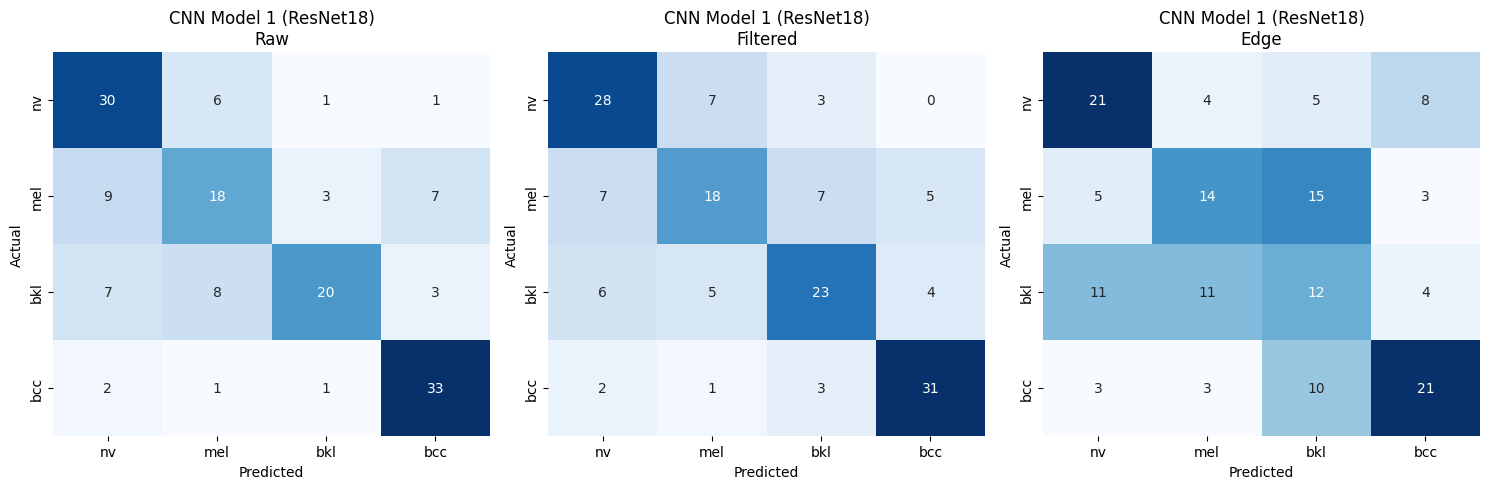

In [27]:
import seaborn as sns

best_overall = run_results_df.loc[run_results_df["Accuracy"].idxmax()]
best_model_name = best_overall["Model"]
print(f"Best-performing model overall: {best_model_name} ({best_overall['Dataset']}, "
      f"{best_overall['Accuracy']:.2f}% accuracy)")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, version in zip(axes, DATASET_VERSIONS):
    cm = all_confusion_task6[(best_model_name, version)]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=SELECTED_CLASSES, yticklabels=SELECTED_CLASSES, ax=ax)
    ax.set_title(f"{best_model_name}\n{version}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("task6_confusion_matrices.png", dpi=150)
plt.show()

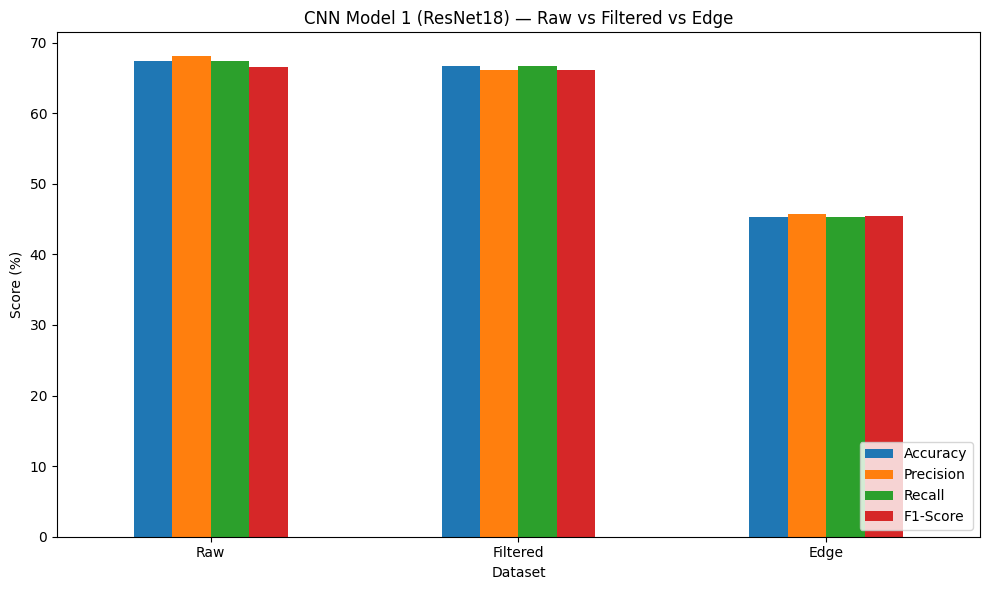

          Accuracy  Precision  Recall  F1-Score
Dataset                                        
Raw          67.33      68.05   67.33     66.54
Filtered     66.67      66.12   66.67     66.18
Edge         45.33      45.72   45.33     45.44


In [28]:
import seaborn as sns

best_model_rows = run_results_df[run_results_df["Model"] == best_model_name].set_index("Dataset").loc[DATASET_VERSIONS]
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score"]

best_model_rows[metrics_to_plot].plot(kind="bar", figsize=(10, 6))
plt.title(f"{best_model_name} — Raw vs Filtered vs Edge")
plt.ylabel("Score (%)")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("task6_bar_chart.png", dpi=150)
plt.show()

print(best_model_rows[metrics_to_plot].round(2))

## Section 8: Push to GitHub

Once you've run everything and are happy with the numbers, gather these into a `Lab 03` folder:
- This notebook (`.ipynb`)
- `table1_noise_effect.csv`, `table2_canny_params.csv`, `table3_classification_comparison.csv`
- The saved figures (`task1_edge_comparison.png`, `task2_noise_effect.png`, `task3_canny_params.png`, `task4_dataset_versions.png`, `task6_confusion_matrices.png`, `task6_bar_chart.png`)
- The `Lab03_Report_and_Questions.md` deliverable (report + discussion questions + viva questions)

In [ ]:
# From a terminal (or a Colab cell prefixed with !), inside your cloned repo:

# git clone https://github.com/<your-username>/<your-repo>.git
# cd <your-repo>
# mkdir -p "Lab 03"
# cp /path/to/this/notebook.ipynb "Lab 03/"
# cp table1_noise_effect.csv table2_canny_params.csv table3_classification_comparison.csv "Lab 03/"
# cp task*.png "Lab 03/"
# cp /path/to/Lab03_Report_and_Questions.md "Lab 03/"
# git add "Lab 03"
# git commit -m "Add Lab 03: Edge Detection and Classification Comparison"
# git push origin main